# Mojito timing and orbits file
This notebook describes the Mojito timing aspects and derives the orbits file generation.

Import statements:

In [13]:
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits
import numpy as np
from h5py import File, Dataset

## Definition of number of time steps `size_l0`
CD1/Mojito Light is composed of 2 years of valid science data (no gaps/glitches considered), to be used for GlobalFit purposes. More specifically, we require 2 years of L1 data, at a sampling frequency of 4 Hz (0.25 s time step). The corresponding size (i.e., number of time steps) is the following:

In [14]:
OrbitsFolder = '/scratch/project_2004833/depoorter/data/constellation'

In [15]:
DT = 5  # time step in seconds
DURATION_MOJITO_LIGHT = np.ceil(2.0 * ASTRONOMICAL_YEAR / DT) * DT  # duration in seconds, rounded up to integer number of DT
size_l1 = int(np.round(DURATION_MOJITO_LIGHT / DT)) + 1  # plus 1, to cover the full 2 years extent
print(size_l1)

12623261


This size corresponds to the number of L1 data points. As the L01 pipeline `lolipops` trims the incoming L0 dataset by 1000 samples, on both sides, the number of L1 data points to be calculated is:

In [16]:
N_TRIM_LOLIPOPS = 1000  # lolipops.pipelines.mojito.MOJITO_LIGHT_TRIMMING
size_l0 = size_l1 + 2 * N_TRIM_LOLIPOPS
print(size_l0)

12625261


We need 252467200 L0 data points then, sampled at 4 Hz. 

## Definition of `t0_orbits`, `t0_l0`, and `size_orbits`
The preparation of a LISA orbits file relies on a precalculated set of OEM orbits files, which are fed to `lisaorbits` to build a LISA orbits file. In principle, one could rely on the first available data point to define a time reference `t0_l0` for the first L0 data point and for the first orbits data point. However, there are few things to consider:
1. When calculating the first response value at time `t = t0_l0`, one not only needs to know the spacecraft positions at the given `t0_l0` (the receiving spacecraft), but also requires the position of the emitting spacecraft at the given light-travel time before `t0_l0`. In practice, this light travel time is around ~8-9 seconds. The reference time for the L0 data and the one for the orbits file therefore differ by at least 9 seconds. 
2. The response calculation for Galactic binaries relies on a time domain that is extended by a factor `WINDOW_JAXGBRESPONSE` times the length of the required domain, on both sides. For Mojito, we take `WINDOW_JAXGBRESPONSE = 0.5`, which means we require `size_l0 / 2` additional samples before `t0_l0` (and similarly `size_l0 / 2` beyond the required time interval of size `size_l0`). To calculate the response on the extended domain, we require orbits data that start from `t0 - (size_l0 / 2) * DT`, to be decreased by an additional maximum light travel time of ~9 seconds (cf. point 1 above). 
3. Orbits data are defined with a time step `DT_ORBITS` much larger than the data sampling time step `DT`. To make sure we avoid edge effects from interpolating the orbits data on the response time grid, we take an additional 3 orbit time steps as buffer. 

The above 3 points indicate that any initial orbits data point, at a time we define as `t0_orbits`, needs to be well before the `t0_l0` associated with our first L0 data point. We pick `t0_orbits` as the `t_start` of the orignal orbits file data from which the `lisaorbits` file will be generated, augmented with `T_DLTT_ORBITS = 10.0` seconds to allow for a valid first `d_ltt` point (this makes `t0_orbits = t_start + 10.0`, which is identical to the default `t_init` in LISA Orbits). Aside from this, we take `DT_ORBITS = 2e5`, which is a time step which should reduce the upsampling artefacts on the LISA noise data generation:

In [17]:
orbits = OEMOrbits.from_included("esa-trailing")
T_DLTT_ORBITS = 10.0
t0_orbits = orbits.t_start + T_DLTT_ORBITS
DT_ORBITS = 2.0e5

100%|█████████████████████████████████████| 85.1k/85.1k [00:00<00:00, 57.0MB/s]
100%|█████████████████████████████████████| 85.2k/85.2k [00:00<00:00, 62.8MB/s]
100%|█████████████████████████████████████| 85.3k/85.3k [00:00<00:00, 62.5MB/s]
OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [18]:
t0_orbits-10

np.float64(61171229.327664)

In [19]:
252467200/4

63116800.0

In [20]:
63116800-61171229

1945571

From the above points 1-3, we introduce an `ltt_offset` of 9 seconds, our window factor `WINDOW_JAXGBRESPONSE = 0.5`, and `N_ORBIT_BUFFER = 10` as the number of additional interpolation points for the orbits data on the edges of the time domain.

In [10]:
WINDOW_JAXGBRESPONSE = 0.5  # window factor: extends a given time domain of n samples with n/2 additional samples before and n/2 additional samples after
N_ORBIT_BUFFER = 10
ltt_offset = 9.0  # s

Combining points 1, 2, and 3, we can now define `t0_l0` relative to `t0_orbits`.

In [11]:
t0_l0 = t0_orbits + N_ORBIT_BUFFER * DT_ORBITS + WINDOW_JAXGBRESPONSE * size_l0 * DT

In words, `t0_l0` differs from `t0_orbits` by `N_ORBIT_BUFFER` samples times `DT_ORBITS` (as interpolation buffer), augmented with the exact time extension of the windowed domain. For simplicity, we are not including `ltt_offset` here: one could include an additional 9 seconds to cover for the LTT between the emitting and receiving spacecraft, but these 9 seconds fit well within the 2,000,000 seconds interpolation buffer that is associated with the additional orbits samples `N_ORBIT_BUFFER`. (As a side note: by not accounting for 9 additional seconds, we know that the very first orbits evaluation for the Galactic Binary response on an extended domain, for the receiving spacecraft position, will exactly coincide with the 11-th grid point from the orbits file; this could be used for additional orbits-file validation purposes.)

Now, we still need to define the size of the full time grid on which the orbits file will be defined. 


In [12]:
size_orbits = int(np.ceil(((1 + 2 * WINDOW_JAXGBRESPONSE) * size_l0 - 1) * DT / DT_ORBITS)) + 1 + 2 * N_ORBIT_BUFFER
print(size_orbits)

653


Note that this definition carefully considers the difference in size between the response time grid of step size `DT` and the one of the orbits with step size `DT_ORBITS`. It also accounts for `N_ORBIT_BUFFER` additional buffer points at the end of the orbits file (in addition to the one at the start). 

## Definition of `t_init`
`t0_l0`, directly derived from `t0_orbits`, gives a proper time origin for all response calculations (L0 data) and orbit file timings. In principle, it can also be used for referencing all the source parameters. For example, when specifying the `f0` for any Galactic binary catalogue source, one could associate this `f0` with the TCB time `t0_l0` (since, in general, `f0` will hold for only one time instance and will evolve linearly at a rate set by `fdot`). However, this approach turns out to be not very practical for several source types in Mojito.

The response calculation of several Mojito sources relies on the interpolation of precalculated strains in the SSB frame. Since LISA detectors are not located at the SBB, any detector-level response calculation requires the calculation of the corresponding time point at which the SSB-level strain was (in the past) or will be (in the future) identical to the detector-level strain:
$$ h_{+,\mathrm{detector}}(t_\mathrm{TCB})=h_{+,\mathrm{SSB}}(t_\mathrm{TCB}')$$
The (absolute) difference between this $t_\mathrm{TCB}$ and $t_\mathrm{TCB}'$ can be up to $\sim1\,\mathrm{au}/c\approx 500\,\mathrm{s}$ (light travel time when the gravitational wave source, the SSB, and the LISA detector are on one line), augmented with `ltt_offset`$=9\,\mathrm{s}$ (light-travel time between an emitting and a receiving spacecraft, since the response evaluation requires strain information at the level of the emitting detector). Depending on the situation, evaluating the equivalent SSB-level strain may therefore require precalculated strains extending up to 550 seconcds before `t0_l0` (with sufficient margin and having a sufficient number of buffering points for avoiding edge effects). Similarly, up to 550 seconds of pre-calculated strain may be required after the last valid L0 datapoint, for calculating this last response value.

Picking `t0_l0` as the reference time for our source parameters is therefore less practical: a waveform tool required for strain evaluation will generally not allow for reverse calculation of the additional 550 seconds of strain that is required. A more logical choice is to define a new reference time `t_init = t0_l0 - 550.0`, which is the starting point of the time grid of any pre-calculated strain. This avoids calculating strains in the reverse time direction and/or re-evaluating our source parameters on a different reference time (which isn't always straightforward). For simplicity, we assume all source parameters in the Mojito catalogues are defined at this same `t_init`, even for sources for which no interpolation of pre-calculated SSB strains is used.

In addition to this reference time `t_init`, we define a `size_strain` as the number of strain points that need to be evaluated corresponding to the given `size_l0` of L0 data.

In [13]:
T_STRAIN_OFFSET = 550.0  # seconds
t_init = t0_l0 - T_STRAIN_OFFSET
size_strain = size_l0 + int(2 * np.ceil(T_STRAIN_OFFSET / DT))

As we summarize all above in the Section below, we finish this part by setting everything to `None` (avoiding any shadowing by the above variables).

In [14]:
DT = size_l1 = N_TRIM_LOLIPOPS = size_l0 = t0_orbits = T_DLTT_ORBITS = DT_ORBITS = WINDOW_JAXGBRESPONSE = N_ORBIT_BUFFER = ltt_offset = t0_l0 = size_orbits = T_STRAIN_OFFSET = t_init = size_strain = None

## Bringing it all together

In [15]:
2.0 * ASTRONOMICAL_YEAR

63116299.52709119

In [16]:
63116299.75

63116299.75

In [17]:
DT=5
np.ceil(2.0 * ASTRONOMICAL_YEAR / DT) * DT

np.float64(63116300.0)

In [18]:
DT = 5  # time step L0/L1 data, in seconds
DURATION_MOJITO_LIGHT = np.ceil(2.0 * ASTRONOMICAL_YEAR / DT) * DT  # duration of Mojito in seconds, rounded up to fit an integer amounts of DT
DT_ORBITS = 2.0e5  # time step of orbits file, in seconds
T_DLTT_ORBITS = 10.  # time, in seconds
T_STRAIN_OFFSET = 550.  # time offset, in seconds
N_TRIM_LOLIPOPS = 1000  # number of samples to be trimmed. To be replaced by lolipops.pipelines.mojito.MOJITO_LIGHT_TRIMMING
N_ORBIT_BUFFER = 10  # number of samples 
WINDOW_JAXGBRESPONSE = 0.5  # 
OEMORBITS = "esa-trailing"

# time reference, derived from OEM Orbits file
orbits = OEMOrbits.from_included(OEMORBITS)
t0_orbits = float(orbits.t_start) + T_DLTT_ORBITS

# sizes
size_l1 = int(np.round(DURATION_MOJITO_LIGHT / DT)) + 1  # plus 1, to cover the full 2 years extent
size_l0 = size_l1 + 2 * N_TRIM_LOLIPOPS
size_strain = size_l0 + int(2 * np.ceil(T_STRAIN_OFFSET / DT))
size_orbits = int(np.ceil(((1 + 2 * WINDOW_JAXGBRESPONSE) * size_l0 - 1) * DT / DT_ORBITS)) + 1 + 2 * N_ORBIT_BUFFER

# orbits file creation
orbits.write(f"{OrbitsFolder}/esa-trailing-orbits.h5", dt=DT_ORBITS, size=size_orbits, t0=t0_orbits, mode="w")

# time definitions
t0_l0 = t0_orbits + N_ORBIT_BUFFER * DT_ORBITS + WINDOW_JAXGBRESPONSE * size_l0 * DT
t_init = t0_l0 - T_STRAIN_OFFSET

print(f'''
t0_l0 = {t0_l0} 
size_l0 = {size_l0}
t_init = {t_init}
size_strain = {size_strain}
size_l1 = {size_l1}
duration_mojito_light = {DURATION_MOJITO_LIGHT}

''')

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)



t0_l0 = 94734391.827664 
size_l0 = 12625261
t_init = 94733841.827664
size_strain = 12625481
size_l1 = 12623261
duration_mojito_light = 63116300.0




## Generating the groundtracking file accordingly

In [19]:
with File(f"{OrbitsFolder}/groundtrack.h5", "w") as gt:
    with File(f"{OrbitsFolder}/esa-trailing-orbits.h5", "r") as orb:

        # Safely copy attributes if they exist
        for attr in ["t0", "dt", "duration", "size"]:
            if attr in orb.attrs:
                gt.attrs[attr] = orb.attrs[attr]

        # Safely copy datasets if they exist
        x_dataset = orb["tcb/x"]
        assert isinstance(x_dataset, Dataset)
        gt["x"] = x_dataset[:]

        v_dataset = orb["tcb/v"]
        assert isinstance(v_dataset, Dataset)
        gt["v"] = v_dataset[:]

Derive all related timings and check

In [20]:
# check L1-related timings
t0_l1 = t0_l0 + N_TRIM_LOLIPOPS * DT
t_last_l1 = t0_l1 + DURATION_MOJITO_LIGHT
assert abs(t_last_l1 - (t0_l1 + (size_l1 - 1) * DT)) < 1e-10

# check L0-related timings
t_last_l0 = t0_l0 + 2 * N_TRIM_LOLIPOPS * DT + DURATION_MOJITO_LIGHT
assert abs(t_last_l0 - (t0_l0 + (size_l0 - 1) * DT)) < 1e-10

# check strain-related timings
t_last_strain = t_init + 2 * T_STRAIN_OFFSET + 2 * N_TRIM_LOLIPOPS * DT + DURATION_MOJITO_LIGHT
assert abs(t_last_strain - (t_init + (size_strain - 1) * DT)) < 1e-10

# check orbits-related timings
t_last_orbits = t0_orbits + 2 * N_ORBIT_BUFFER * DT_ORBITS + np.ceil(((1 + 2 * WINDOW_JAXGBRESPONSE) * size_l0 - 1) * DT / DT_ORBITS) * DT_ORBITS
t_orbits = t0_orbits + np.arange(size_orbits) * DT_ORBITS
assert abs(t0_orbits - t_orbits[0]) < 1e-10
assert abs(t_last_orbits - t_orbits[-1]) < 1e-10
assert abs((t_last_orbits - t0_orbits) / DT_ORBITS - size_orbits + 1) < 1e-10

# compare L0 and L1 timings
assert abs((t0_l1 - t0_l0) / DT - N_TRIM_LOLIPOPS) < 1e-10
assert abs((t_last_l0 - t_last_l1) / DT - N_TRIM_LOLIPOPS) < 1e-10
assert size_l0 > size_l1

# compare strain and L0 timings
assert abs(t0_l0 - t_init - T_STRAIN_OFFSET) < 1e-10
assert abs(t_last_strain - t_last_l0 - T_STRAIN_OFFSET) < 1e-10
assert size_strain > size_l0

# compare orbits timings and timings related to extended L0 domain
ltt_offset = 9.0  # s: we require orbits data 9 seconds before first extended domain L0 data point
t0_l0_extended = t0_l0 - WINDOW_JAXGBRESPONSE * size_l0 * DT
t_last_l0_extended = t0_l0 + ((1 + WINDOW_JAXGBRESPONSE) * size_l0 - 1) * DT
assert t0_orbits < t0_l0_extended - ltt_offset
assert abs(t0_orbits + N_ORBIT_BUFFER * DT_ORBITS - t0_l0_extended) < 1e-10
assert abs(t_last_orbits - N_ORBIT_BUFFER * DT_ORBITS - t_last_l0_extended) < DT_ORBITS  # this one checks if orbits file is minimal, w.r.t. extended L0 domain

# sequence of Mojito events
sequence = {
    "t0_orbits": t0_orbits,
    "t0_orbits + 3*DT_ORBITS": t0_l0_extended,
    "t_init = t0_l0 - 550s": t_init,
    "t0_l0": t0_l0,
    "t0_l1 = t0_l0 + 250s": t0_l1,
    "t_last_l1 = t0_l1 + 2y": t_last_l1,
    "t_last_l0 = t0_l0 + 2y + 500s": t_last_l0,
    "t_last_strain = t_init + 2y + 500s + 1100s": t_last_strain,
    "t0_l0 + ((1 + window) * size_l0 - 1) * DT": t_last_l0_extended,
    "t_last_orbits - 3*DT_ORBITS": t_last_orbits - N_ORBIT_BUFFER * DT_ORBITS,
    "t_last_orbits": t_last_orbits
}

# assert if order correct
sequence_times = np.array(list(sequence.values()))
assert np.all(sequence_times == np.sort(sequence_times))

## Overview plot
To improve the overview of the Mojito timings, we derive an overall plot. Since the absolute time values are large, and the intervals between several important events is strongly variable in size, we assign rather arbitrary rescaling values (still preserving, obviously, the sequence of events). 

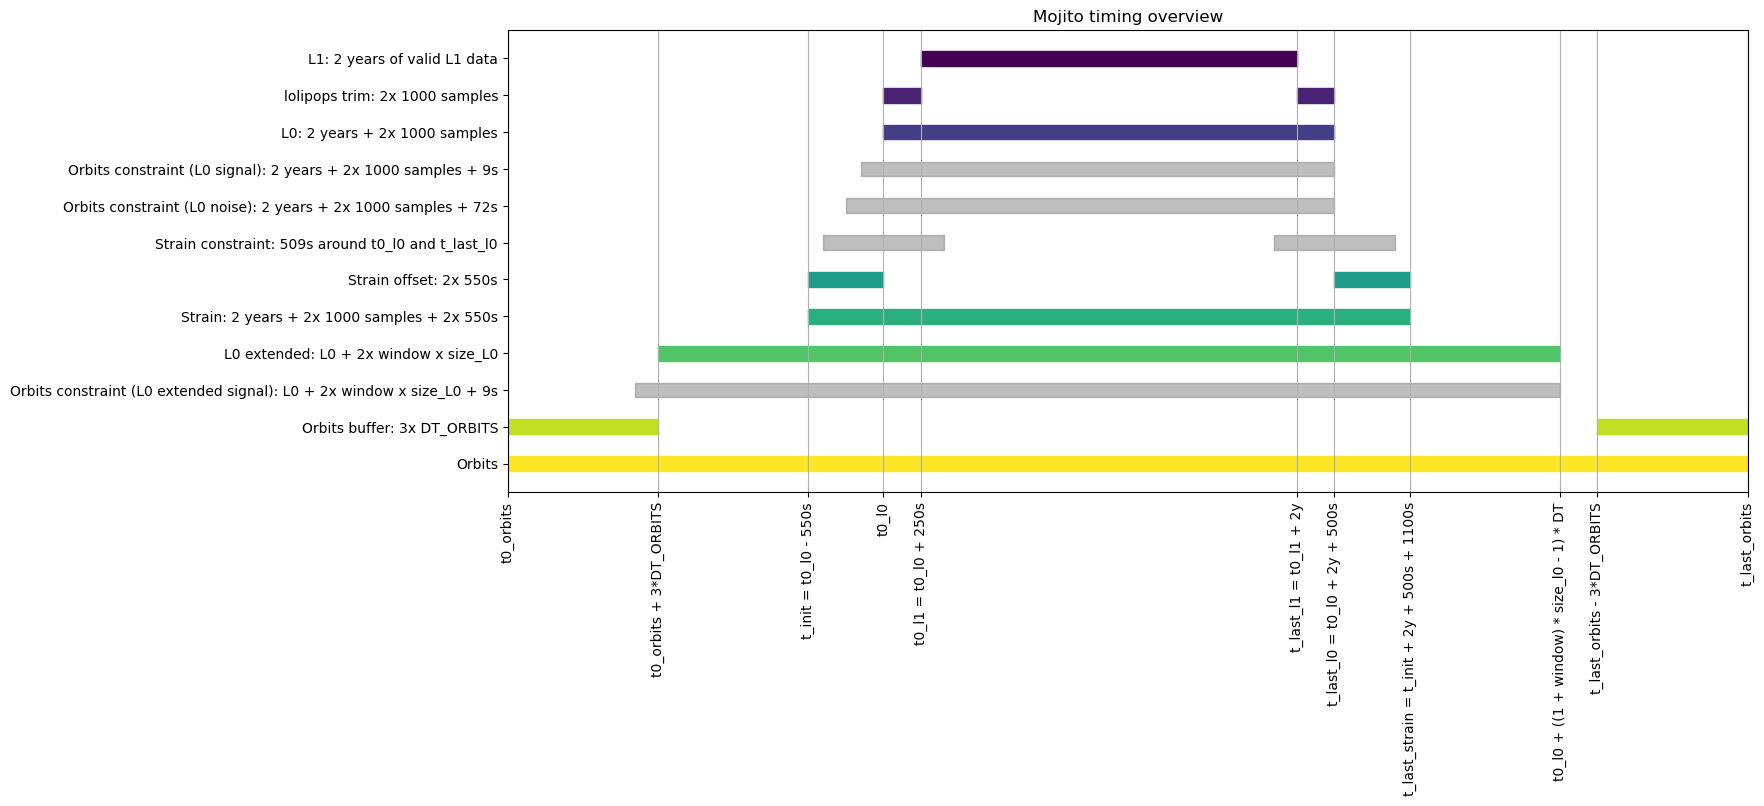

In [21]:
# actual time values are not practical for plotting, so we define scaling values
sequence_scales = {
    "t0_orbits": 0,
    "t0_orbits + 3*DT_ORBITS": 2,
    "t_init = t0_l0 - 550s": 4,
    "t0_l0": 5,
    "t0_l1 = t0_l0 + 250s": 5.5,
    "t_last_l1 = t0_l1 + 2y": 10.5,
    "t_last_l0 = t0_l0 + 2y + 500s": 11,
    "t_last_strain = t_init + 2y + 500s + 1100s": 12,
    "t0_l0 + ((1 + window) * size_l0 - 1) * DT": 14,
    "t_last_orbits - 3*DT_ORBITS": 14.5,
    "t_last_orbits": 16.5
}

delta_scales = {
    "9s": 0.3,
    "72s": 0.5,
    "509s": 0.8,
}

# check if we don't mess with the sequence of events
assert np.all(np.argsort(sequence_times) == np.argsort(np.array(list(sequence_scales.values()))))
assert np.all(np.array(list(delta_scales.values())) == np.sort(np.array(list(delta_scales.values()))))

# each bar element will result in a broken bar plot, with the related time events
bars = {
    "L1: 2 years of valid L1 data": [("t0_l1 = t0_l0 + 250s", "t_last_l1 = t0_l1 + 2y")], 
    "lolipops trim: 2x 1000 samples": [("t0_l0", "t0_l1 = t0_l0 + 250s"), ("t_last_l1 = t0_l1 + 2y", "t_last_l0 = t0_l0 + 2y + 500s")], 
    "L0: 2 years + 2x 1000 samples": [("t0_l0", "t_last_l0 = t0_l0 + 2y + 500s")], 
    "Orbits constraint (L0 signal): 2 years + 2x 1000 samples + 9s": [(sequence_scales["t0_l0"] - delta_scales["9s"], sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - (sequence_scales["t0_l0"] - delta_scales["9s"]))],
    "Orbits constraint (L0 noise): 2 years + 2x 1000 samples + 72s": [(sequence_scales["t0_l0"] - delta_scales["72s"], sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - (sequence_scales["t0_l0"] - delta_scales["72s"]))], 
    "Strain constraint: 509s around t0_l0 and t_last_l0": [(sequence_scales["t0_l0"] - delta_scales["509s"], 2 * delta_scales["509s"]), (sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - delta_scales["509s"], 2 * delta_scales["509s"])],
    "Strain offset: 2x 550s": [("t_init = t0_l0 - 550s", "t0_l0"), ("t_last_l0 = t0_l0 + 2y + 500s", "t_last_strain = t_init + 2y + 500s + 1100s")], 
    "Strain: 2 years + 2x 1000 samples + 2x 550s": [("t_init = t0_l0 - 550s", "t_last_strain = t_init + 2y + 500s + 1100s")], 
    "L0 extended: L0 + 2x window x size_L0": [("t0_orbits + 3*DT_ORBITS", "t0_l0 + ((1 + window) * size_l0 - 1) * DT")], 
    "Orbits constraint (L0 extended signal): L0 + 2x window x size_L0 + 9s": [(sequence_scales["t0_orbits + 3*DT_ORBITS"] - delta_scales["9s"], sequence_scales["t0_l0 + ((1 + window) * size_l0 - 1) * DT"] - (sequence_scales["t0_orbits + 3*DT_ORBITS"] - delta_scales["9s"]))],
    "Orbits buffer: 3x DT_ORBITS": [("t0_orbits", "t0_orbits + 3*DT_ORBITS"), ("t_last_orbits - 3*DT_ORBITS", "t_last_orbits")], 
    "Orbits": [("t0_orbits", "t_last_orbits")]
}

# some bars only visualize a constraint, from which we don't derive an explicit timing (since the edges are variable)
constraints_without_timing = [
    "Orbits constraint (L0 signal): 2 years + 2x 1000 samples + 9s", 
    "Orbits constraint (L0 noise): 2 years + 2x 1000 samples + 72s",
    "Strain constraint: 509s around t0_l0 and t_last_l0", 
    "Orbits constraint (L0 extended signal): L0 + 2x window x size_L0 + 9s" 
]

import matplotlib.pyplot as plt
%matplotlib inline

# actual plot
colors = plt.cm.viridis(np.linspace(0, 1, len(bars)))
fig, ax = plt.subplots()
fig.set_size_inches((16,6))
loc_y = -0.2
for i, (key, value) in enumerate(bars.items()):
    if key in constraints_without_timing:
        ax.broken_barh(value, 
                     (loc_y, 0.4), color = "tab:grey", alpha=.5)
    else:
        ax.broken_barh([(sequence_scales[v[0]], sequence_scales[v[1]] - 
                        sequence_scales[v[0]]) for v in value], 
                        (loc_y, 0.4), color=colors[i])
    loc_y += 1.0
ax.set_xlim(0, 16.5)
ax.set_yticks(range(len(bars)), labels=list(bars.keys()))
ax.invert_yaxis()
ax.set_title("Mojito timing overview")
ax.xaxis.grid(True)
plt.xticks(list(sequence_scales.values()), list(sequence_scales.keys()))
_ = ax.tick_params(axis='x', rotation=90)



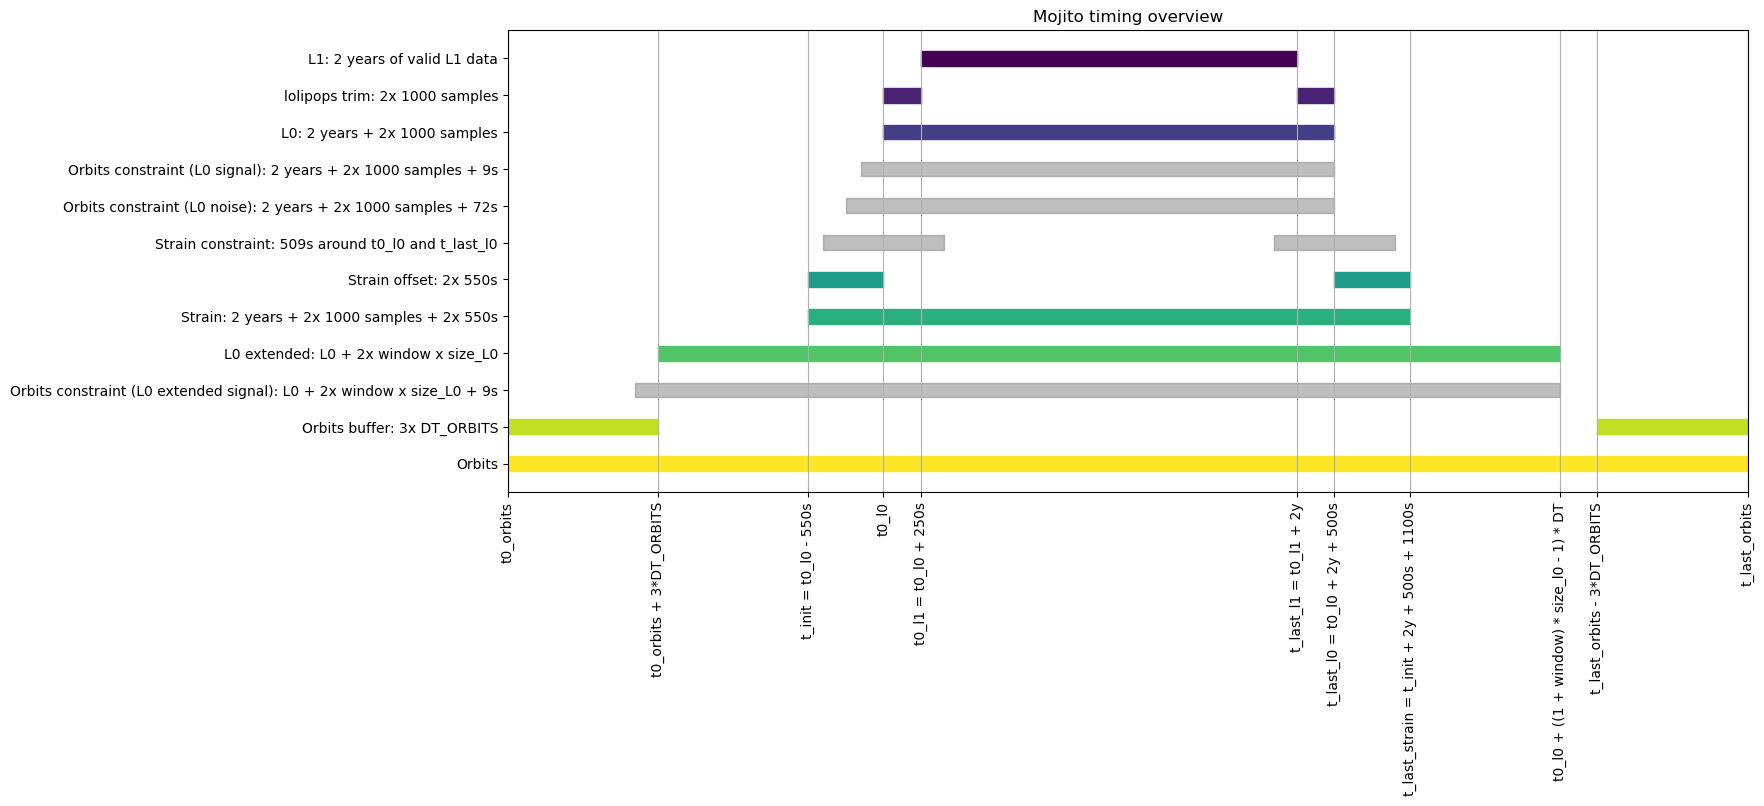

In [22]:
# actual time values are not practical for plotting, so we define scaling values
sequence_scales = {
    "t0_orbits": 0,
    "t0_orbits + 3*DT_ORBITS": 2,
    "t_init = t0_l0 - 550s": 4,
    "t0_l0": 5,
    "t0_l1 = t0_l0 + 250s": 5.5,
    "t_last_l1 = t0_l1 + 2y": 10.5,
    "t_last_l0 = t0_l0 + 2y + 500s": 11,
    "t_last_strain = t_init + 2y + 500s + 1100s": 12,
    "t0_l0 + ((1 + window) * size_l0 - 1) * DT": 14,
    "t_last_orbits - 3*DT_ORBITS": 14.5,
    "t_last_orbits": 16.5
}

delta_scales = {
    "9s": 0.3,
    "72s": 0.5,
    "509s": 0.8,
}

# check if we don't mess with the sequence of events
assert np.all(np.argsort(sequence_times) == np.argsort(np.array(list(sequence_scales.values()))))
assert np.all(np.array(list(delta_scales.values())) == np.sort(np.array(list(delta_scales.values()))))

# each bar element will result in a broken bar plot, with the related time events
bars = {
    "L1: 2 years of valid L1 data": [("t0_l1 = t0_l0 + 250s", "t_last_l1 = t0_l1 + 2y")], 
    "lolipops trim: 2x 1000 samples": [("t0_l0", "t0_l1 = t0_l0 + 250s"), ("t_last_l1 = t0_l1 + 2y", "t_last_l0 = t0_l0 + 2y + 500s")], 
    "L0: 2 years + 2x 1000 samples": [("t0_l0", "t_last_l0 = t0_l0 + 2y + 500s")], 
    "Orbits constraint (L0 signal): 2 years + 2x 1000 samples + 9s": [(sequence_scales["t0_l0"] - delta_scales["9s"], sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - (sequence_scales["t0_l0"] - delta_scales["9s"]))],
    "Orbits constraint (L0 noise): 2 years + 2x 1000 samples + 72s": [(sequence_scales["t0_l0"] - delta_scales["72s"], sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - (sequence_scales["t0_l0"] - delta_scales["72s"]))], 
    "Strain constraint: 509s around t0_l0 and t_last_l0": [(sequence_scales["t0_l0"] - delta_scales["509s"], 2 * delta_scales["509s"]), (sequence_scales["t_last_l0 = t0_l0 + 2y + 500s"] - delta_scales["509s"], 2 * delta_scales["509s"])],
    "Strain offset: 2x 550s": [("t_init = t0_l0 - 550s", "t0_l0"), ("t_last_l0 = t0_l0 + 2y + 500s", "t_last_strain = t_init + 2y + 500s + 1100s")], 
    "Strain: 2 years + 2x 1000 samples + 2x 550s": [("t_init = t0_l0 - 550s", "t_last_strain = t_init + 2y + 500s + 1100s")], 
    "L0 extended: L0 + 2x window x size_L0": [("t0_orbits + 3*DT_ORBITS", "t0_l0 + ((1 + window) * size_l0 - 1) * DT")], 
    "Orbits constraint (L0 extended signal): L0 + 2x window x size_L0 + 9s": [(sequence_scales["t0_orbits + 3*DT_ORBITS"] - delta_scales["9s"], sequence_scales["t0_l0 + ((1 + window) * size_l0 - 1) * DT"] - (sequence_scales["t0_orbits + 3*DT_ORBITS"] - delta_scales["9s"]))],
    "Orbits buffer: 3x DT_ORBITS": [("t0_orbits", "t0_orbits + 3*DT_ORBITS"), ("t_last_orbits - 3*DT_ORBITS", "t_last_orbits")], 
    "Orbits": [("t0_orbits", "t_last_orbits")]
}

# some bars only visualize a constraint, from which we don't derive an explicit timing (since the edges are variable)
constraints_without_timing = [
    "Orbits constraint (L0 signal): 2 years + 2x 1000 samples + 9s", 
    "Orbits constraint (L0 noise): 2 years + 2x 1000 samples + 72s",
    "Strain constraint: 509s around t0_l0 and t_last_l0", 
    "Orbits constraint (L0 extended signal): L0 + 2x window x size_L0 + 9s" 
]

import matplotlib.pyplot as plt
%matplotlib inline

# actual plot
colors = plt.cm.viridis(np.linspace(0, 1, len(bars)))
fig, ax = plt.subplots()
fig.set_size_inches((16,6))
loc_y = -0.2
for i, (key, value) in enumerate(bars.items()):
    if key in constraints_without_timing:
        ax.broken_barh(value, 
                     (loc_y, 0.4), color = "tab:grey", alpha=.5)
    else:
        ax.broken_barh([(sequence_scales[v[0]], sequence_scales[v[1]] - 
                        sequence_scales[v[0]]) for v in value], 
                        (loc_y, 0.4), color=colors[i])
    loc_y += 1.0
ax.set_xlim(0, 16.5)
ax.set_yticks(range(len(bars)), labels=list(bars.keys()))
ax.invert_yaxis()
ax.set_title("Mojito timing overview")
ax.xaxis.grid(True)
plt.xticks(list(sequence_scales.values()), list(sequence_scales.keys()))
_ = ax.tick_params(axis='x', rotation=90)



In [25]:
### TIMING ###
# for a full discussion, see lisasim/Timing/timing.ipynb
dt = 5
mojito_light_duration= 63116299.75    # seconds
strain_offset= 550.0   # seconds
size_l1= 12623260      # number of samples
trim_lolipops= 1000    # number of samples
size_l0= 1262336       # number of samples
t0_l0= 94729639.327664    # seconds
t_init= 94729089.327664   # seconds
size_strain= 12623580   # number of samples

t0_l1 = t0_l0 + trim_lolipops * dt

t0_flr = t0_l1 - t0_orbits
t0_flr

np.float64(33563400.0)

In [21]:
t0_orbits

np.float64(61171239.327664)

In [9]:
t0_l1 = t0_l0 + trim_lolipops * dt

In [10]:
t0_l1

94734639.327664

In [29]:
t0_l1 + dt * size_l1  + t0_l0 - t_init

157851489.32766402

In [27]:
157851489.32766402 / ASTRONOMICAL_YEAR

5.001924717082312

NameError: name 'esa' is not defined

In [22]:
t0_l1 - t0_orbits

np.float64(33563400.0)

In [ ]:
33563400.0

In [23]:
33568152.5

33568152.5

In [24]:
33568152.5 - 33563400.0

4752.5

In [3]:
252471600/20

12623580.0